In [ ]:
recent_data = ...

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Better chart visibility
plt.rcParams['figure.figsize'] = (10,5)

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
df = pd.read_csv("ipl_data.csv")

df.head()

/tmp/ipykernel_4954/118060174.py:1: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("ipl_data.csv")


,match_id,date,season,event,venue,city,team1,team2,toss_winner,toss_decision,...,non_striker,runs_batter,runs_extras,runs_total,extras_wides,extras_noballs,extras_byes,extras_legbyes,wicket_kind,wicket_player_out
0,1082591,2017-04-05,2017,Indian Premier League,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,...,S Dhawan,0,0,0,0,0,0,0,NaN,NaN
1,1082591,2017-04-05,2017,Indian Premier League,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,...,S Dhawan,0,0,0,0,0,0,0,NaN,NaN
2,1082591,2017-04-05,2017,Indian Premier League,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,...,S Dhawan,4,0,4,0,0,0,0,NaN,NaN
3,1082591,2017-04-05,2017,Indian Premier League,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,...,S Dhawan,0,0,0,0,0,0,0,NaN,NaN
4,1082591,2017-04-05,2017,Indian Premier League,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,...,S Dhawan,0,2,2,2,0,0,0,NaN,NaN


In [ ]:
print(df.shape)

print(df.columns)

df.info()

df.isnull().sum()

(289673, 30)
Index(['match_id', 'date', 'season', 'event', 'venue', 'city', 'team1',
       'team2', 'toss_winner', 'toss_decision', 'winner', 'win_by_runs',
       'win_by_wickets', 'player_of_match', 'innings', 'batting_team', 'over',
       'ball', 'batter', 'bowler', 'non_striker', 'runs_batter', 'runs_extras',
       'runs_total', 'extras_wides', 'extras_noballs', 'extras_byes',
       'extras_legbyes', 'wicket_kind', 'wicket_player_out'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 289673 entries, 0 to 289672
Data columns (total 30 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   match_id           289673 non-null  int64  
 1   date               289673 non-null  object 
 2   season             289673 non-null  object 
 3   event              289673 non-null  object 
 4   venue              289673 non-null  object 
 5   city               277276 non-null  object 
 6   team1              28

,0
match_id,0
date,0
season,0
event,0
venue,0
city,12397
team1,0
team2,0
toss_winner,0
toss_decision,0


In [ ]:
print(df.shape)


(289673, 30)


In [ ]:
df.columns

Index(['match_id', 'date', 'season', 'event', 'venue', 'city', 'team1',
       'team2', 'toss_winner', 'toss_decision', 'winner', 'win_by_runs',
       'win_by_wickets', 'player_of_match', 'innings', 'batting_team', 'over',
       'ball', 'batter', 'bowler', 'non_striker', 'runs_batter', 'runs_extras',
       'runs_total', 'extras_wides', 'extras_noballs', 'extras_byes',
       'extras_legbyes', 'wicket_kind', 'wicket_player_out'],
      dtype='object')

In [ ]:
missing = (df.isnull().sum() / len(df)) * 100

missing.sort_values(ascending=False)

,0
wicket_kind,95.026806
wicket_player_out,95.026806
win_by_runs,53.897326
win_by_wickets,47.821854
city,4.279653
player_of_match,0.285840
venue,0.000000
event,0.000000
season,0.000000
team1,0.000000


In [ ]:
recent_data = df.copy()

# Fill some missing values
recent_data['city'] = recent_data['city'].fillna('Unknown')

recent_data['wicket_kind'] = recent_data['wicket_kind'].fillna('No Wicket')

recent_data['wicket_player_out'] = recent_data['wicket_player_out'].fillna('None')

print("Cleaning done!")

Cleaning done!


In [ ]:
toss_match_win = (recent_data['toss_winner'] == recent_data['winner'])

toss_match_win.head()

,0
0,False
1,False
2,False
3,False
4,False


In [ ]:
toss_win_percentage = toss_match_win.mean() * 100

print(f"Toss winner also won the match in {toss_win_percentage:.2f}% matches")

Toss winner also won the match in 50.20% matches


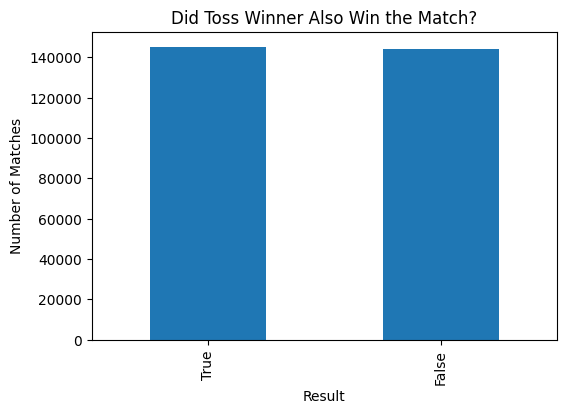

In [ ]:
result_counts = toss_match_win.value_counts()

plt.figure(figsize=(6,4))

result_counts.plot(kind='bar')

plt.title("Did Toss Winner Also Win the Match?")
plt.xlabel("Result")
plt.ylabel("Number of Matches")

plt.show()

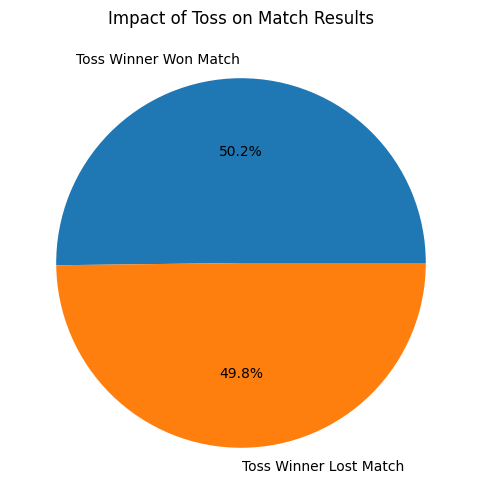

In [ ]:
labels = ['Toss Winner Won Match', 'Toss Winner Lost Match']

sizes = result_counts.values

plt.figure(figsize=(6,6))

plt.pie(sizes, labels=labels, autopct='%1.1f%%')

plt.title("Impact of Toss on Match Results")

plt.show()

In [ ]:
first_innings = recent_data[recent_data['innings'] == 1]

first_innings.head()

,match_id,date,season,event,venue,city,team1,team2,toss_winner,toss_decision,...,non_striker,runs_batter,runs_extras,runs_total,extras_wides,extras_noballs,extras_byes,extras_legbyes,wicket_kind,wicket_player_out
0,1082591,2017-04-05,2017,Indian Premier League,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,...,S Dhawan,0,0,0,0,0,0,0,No Wicket,None
1,1082591,2017-04-05,2017,Indian Premier League,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,...,S Dhawan,0,0,0,0,0,0,0,No Wicket,None
2,1082591,2017-04-05,2017,Indian Premier League,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,...,S Dhawan,4,0,4,0,0,0,0,No Wicket,None
3,1082591,2017-04-05,2017,Indian Premier League,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,...,S Dhawan,0,0,0,0,0,0,0,No Wicket,None
4,1082591,2017-04-05,2017,Indian Premier League,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,...,S Dhawan,0,2,2,2,0,0,0,No Wicket,None


In [ ]:
venue_scores = first_innings.groupby(
    ['match_id', 'venue', 'batting_team']
)['runs_total'].sum().reset_index()

venue_scores.head()

,match_id,venue,batting_team,runs_total
0,335982,M Chinnaswamy Stadium,Kolkata Knight Riders,222
1,335983,"Punjab Cricket Association Stadium, Mohali",Chennai Super Kings,240
2,335984,Feroz Shah Kotla,Rajasthan Royals,129
3,335985,Wankhede Stadium,Mumbai Indians,165
4,335986,Eden Gardens,Deccan Chargers,110


In [ ]:
avg_venue_scores = venue_scores.groupby('venue')['runs_total'].mean().reset_index()

avg_venue_scores = avg_venue_scores.sort_values(by='runs_total', ascending=False)

avg_venue_scores.head(10)


,venue,runs_total
30,Maharaja Yadavindra Singh International Cricke...,217.000000
12,Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket St...,208.750000
40,"Punjab Cricket Association IS Bindra Stadium, ...",197.800000
1,"Arun Jaitley Stadium, Delhi",195.500000
19,"Himachal Pradesh Cricket Association Stadium, ...",194.333333
44,"Rajiv Gandhi International Stadium, Uppal, Hyd...",192.240000
48,"Sawai Mansingh Stadium, Jaipur",191.368421
24,"M Chinnaswamy Stadium, Bengaluru",190.375000
15,"Eden Gardens, Kolkata",189.370370
33,"Narendra Modi Stadium, Ahmedabad",185.947368


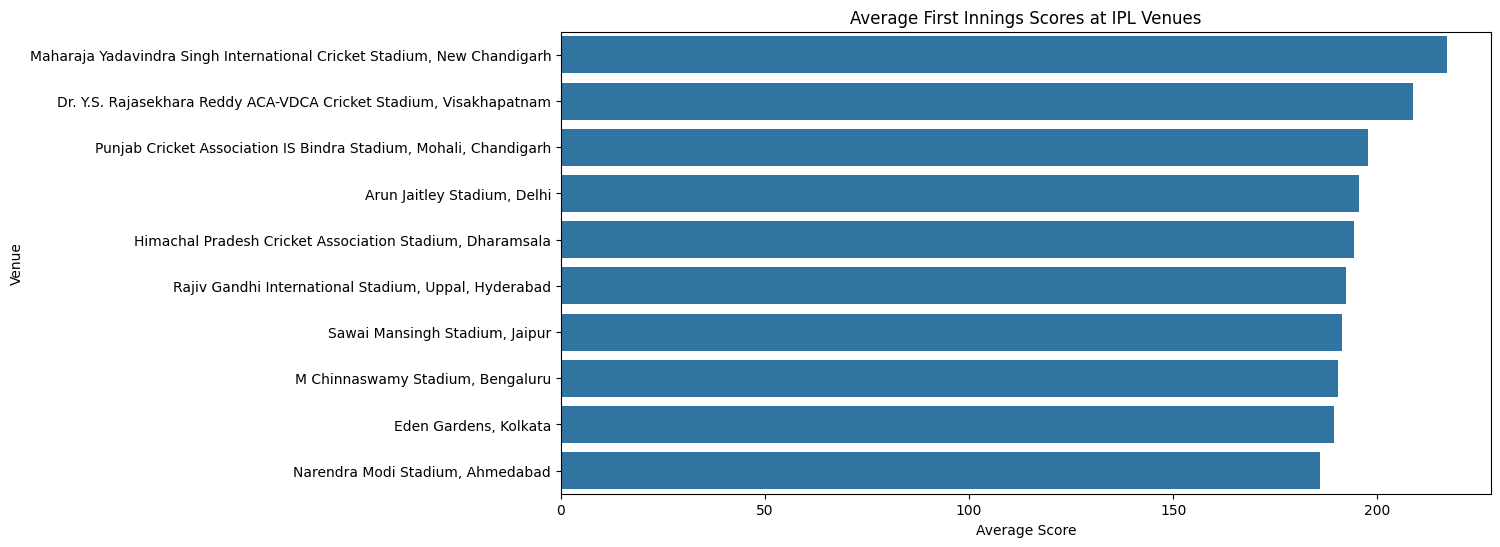

In [ ]:
top_venues = avg_venue_scores.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_venues,
    x='runs_total',
    y='venue'
)

plt.title("Average First Innings Scores at IPL Venues")

plt.xlabel("Average Score")
plt.ylabel("Venue")

plt.show()

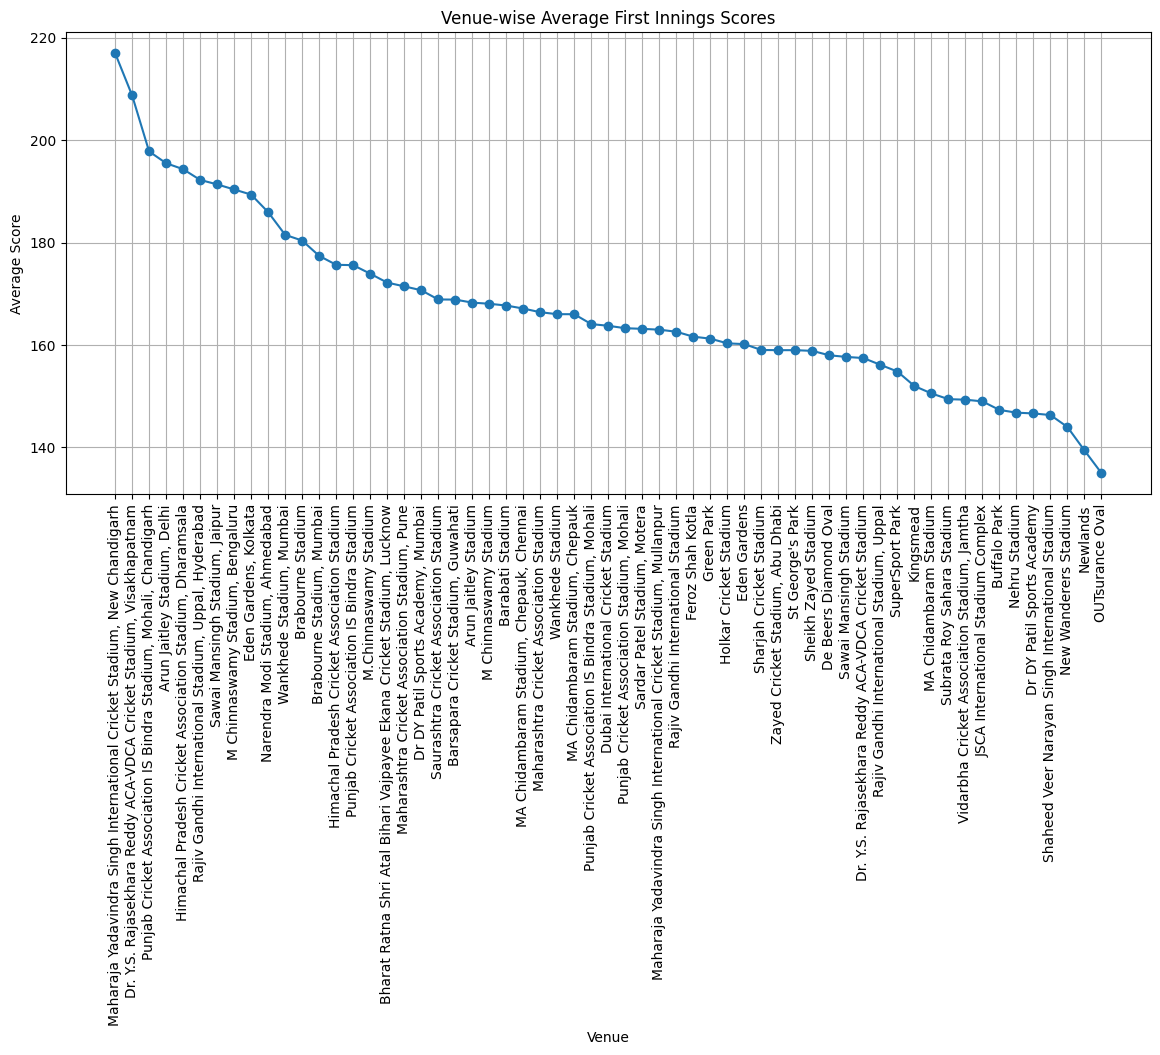

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(
    avg_venue_scores['venue'],
    avg_venue_scores['runs_total'],
    marker='o'
)

plt.xticks(rotation=90)

plt.title("Venue-wise Average First Innings Scores")

plt.xlabel("Venue")
plt.ylabel("Average Score")

plt.grid(True)

plt.show()

In [ ]:
powerplay = recent_data[recent_data['over'] <= 6]

powerplay.head()

,match_id,date,season,event,venue,city,team1,team2,toss_winner,toss_decision,...,non_striker,runs_batter,runs_extras,runs_total,extras_wides,extras_noballs,extras_byes,extras_legbyes,wicket_kind,wicket_player_out
0,1082591,2017-04-05,2017,Indian Premier League,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,...,S Dhawan,0,0,0,0,0,0,0,No Wicket,None
1,1082591,2017-04-05,2017,Indian Premier League,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,...,S Dhawan,0,0,0,0,0,0,0,No Wicket,None
2,1082591,2017-04-05,2017,Indian Premier League,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,...,S Dhawan,4,0,4,0,0,0,0,No Wicket,None
3,1082591,2017-04-05,2017,Indian Premier League,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,...,S Dhawan,0,0,0,0,0,0,0,No Wicket,None
4,1082591,2017-04-05,2017,Indian Premier League,"Rajiv Gandhi International Stadium, Uppal",Hyderabad,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,...,S Dhawan,0,2,2,2,0,0,0,No Wicket,None


In [ ]:
pp_runs = powerplay.groupby(
    ['match_id', 'batting_team']
)['runs_total'].sum().reset_index()

pp_runs.head()

,match_id,batting_team,runs_total
0,335982,Kolkata Knight Riders,68
1,335982,Royal Challengers Bangalore,33
2,335983,Chennai Super Kings,62
3,335983,Kings XI Punjab,69
4,335984,Delhi Daredevils,59


In [ ]:
match_winners = recent_data[['match_id', 'winner']].drop_duplicates()

pp_runs = pp_runs.merge(match_winners, on='match_id')

pp_runs.head()

,match_id,batting_team,runs_total,winner
0,335982,Kolkata Knight Riders,68,Kolkata Knight Riders
1,335982,Royal Challengers Bangalore,33,Kolkata Knight Riders
2,335983,Chennai Super Kings,62,Chennai Super Kings
3,335983,Kings XI Punjab,69,Chennai Super Kings
4,335984,Delhi Daredevils,59,Delhi Daredevils


In [ ]:
pp_runs['team_won'] = pp_runs['batting_team'] == pp_runs['winner']

pp_runs.head()

,match_id,batting_team,runs_total,winner,team_won
0,335982,Kolkata Knight Riders,68,Kolkata Knight Riders,True
1,335982,Royal Challengers Bangalore,33,Kolkata Knight Riders,False
2,335983,Chennai Super Kings,62,Chennai Super Kings,True
3,335983,Kings XI Punjab,69,Chennai Super Kings,False
4,335984,Delhi Daredevils,59,Delhi Daredevils,True


In [ ]:
avg_pp = pp_runs.groupby('team_won')['runs_total'].mean()

print(avg_pp)

team_won
False    52.056589
True     58.628667
Name: runs_total, dtype: float64


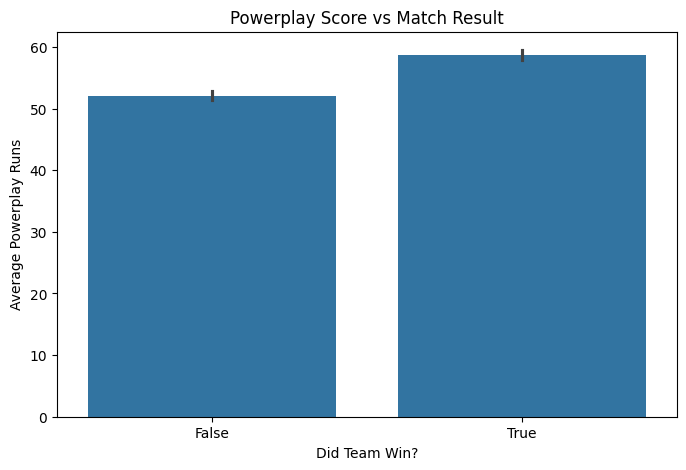

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=pp_runs,
    x='team_won',
    y='runs_total'
)

plt.title("Powerplay Score vs Match Result")

plt.xlabel("Did Team Win?")
plt.ylabel("Average Powerplay Runs")

plt.show()

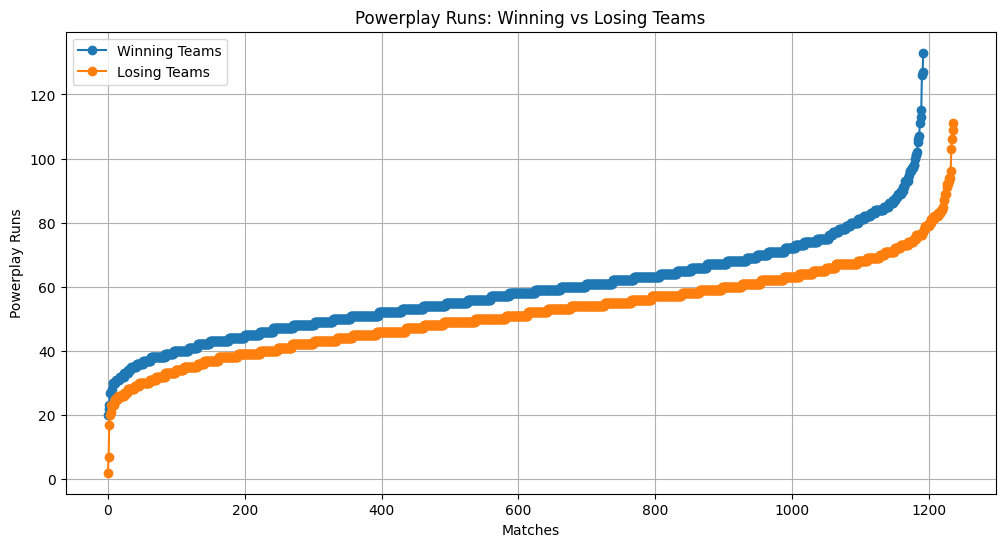

In [ ]:
# Separate winning and losing teams

won_matches = pp_runs[pp_runs['team_won'] == True]
lost_matches = pp_runs[pp_runs['team_won'] == False]

# Sort for smooth lines
won_matches = won_matches.sort_values(by='runs_total')
lost_matches = lost_matches.sort_values(by='runs_total')

plt.figure(figsize=(12,6))

# Winning teams line
plt.plot(
    won_matches['runs_total'].values,
    label='Winning Teams',
    marker='o'
)

# Losing teams line
plt.plot(
    lost_matches['runs_total'].values,
    label='Losing Teams',
    marker='o'
)

plt.title("Powerplay Runs: Winning vs Losing Teams")

plt.xlabel("Matches")
plt.ylabel("Powerplay Runs")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
batter_stats = recent_data.groupby('batter').agg({
    'runs_batter': 'sum',
    'ball': 'count'
}).reset_index()

batter_stats.columns = ['batter', 'total_runs', 'balls_faced']

batter_stats.head()


,batter,total_runs,balls_faced
0,A Ashish Reddy,280,196
1,A Badoni,1135,865
2,A Chandila,4,7
3,A Chopra,53,75
4,A Choudhary,25,20


In [ ]:
batter_stats['strike_rate'] = (
    batter_stats['total_runs'] / batter_stats['balls_faced']
) * 100

batter_stats.head()

,batter,total_runs,balls_faced,strike_rate
0,A Ashish Reddy,280,196,142.857143
1,A Badoni,1135,865,131.213873
2,A Chandila,4,7,57.142857
3,A Chopra,53,75,70.666667
4,A Choudhary,25,20,125.000000


In [ ]:
batter_stats = batter_stats[
    batter_stats['balls_faced'] > 300
]

In [ ]:
batter_stats['impact_score'] = (
    batter_stats['total_runs'] * 0.6 +
    batter_stats['strike_rate'] * 0.4
)

batter_stats.head()

,batter,total_runs,balls_faced,strike_rate,impact_score
1,A Badoni,1135,865,131.213873,733.485549
11,A Mishra,381,440,86.590909,263.236364
16,A Raghuvanshi,731,531,137.664783,493.665913
18,A Symonds,974,781,124.711908,634.284763
31,AB de Villiers,5181,3487,148.580442,3168.032177


In [ ]:
top_impact = batter_stats.sort_values(
    by='impact_score',
    ascending=False
)

top_impact.head(10)

,batter,total_runs,balls_faced,strike_rate,impact_score
686,V Kohli,9050,6942,130.365889,5482.146356
525,RG Sharma,7269,5605,129.687779,4413.275112
561,S Dhawan,6769,5483,123.454313,4110.781725
158,DA Warner,6567,4849,135.429986,3994.371994
310,KL Rahul,5680,4205,135.077289,3462.030916
595,SK Raina,5536,4177,132.535312,3374.614125
408,MS Dhoni,5439,4101,132.626189,3316.450475
51,AM Rahane,5237,4296,121.904097,3190.961639
31,AB de Villiers,5181,3487,148.580442,3168.032177
623,SV Samson,5106,3721,137.221177,3118.488471


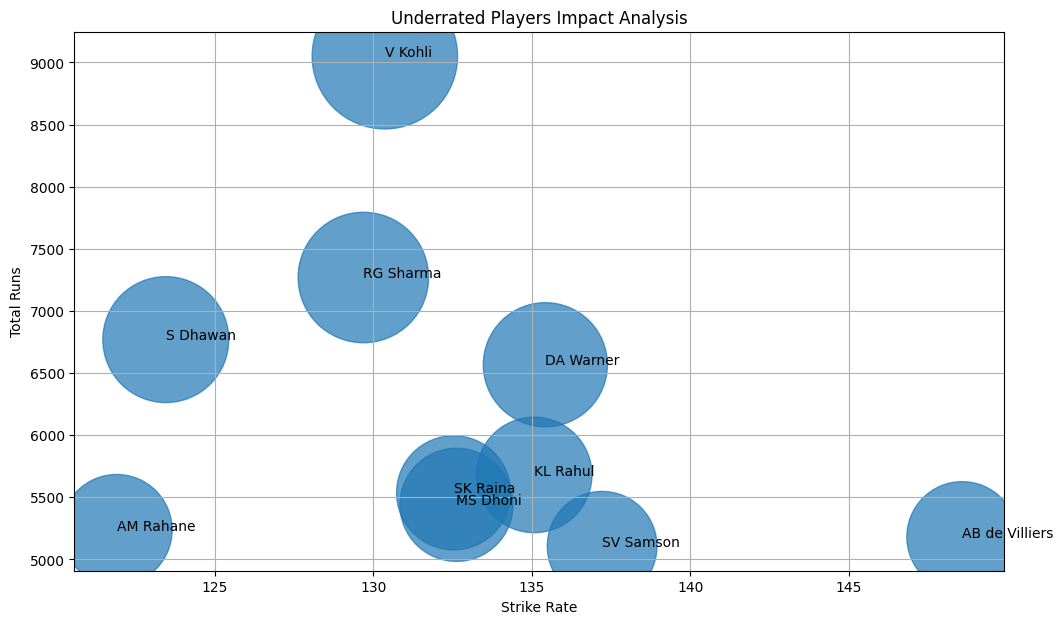

In [ ]:
top10 = top_impact.head(10)

plt.figure(figsize=(12,7))

scatter = plt.scatter(
    top10['strike_rate'],
    top10['total_runs'],
    s=top10['impact_score'] * 2,
    alpha=0.7
)

# Player names
for i in range(len(top10)):
    plt.text(
        top10['strike_rate'].iloc[i],
        top10['total_runs'].iloc[i],
        top10['batter'].iloc[i]
    )

plt.title("Underrated Players Impact Analysis")

plt.xlabel("Strike Rate")
plt.ylabel("Total Runs")

plt.grid(True)

plt.show()

/tmp/ipykernel_5819/3511667714.py:8: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("ipl_data.csv")


                   batting_team  runs_total
8   Royal Challengers Bangalore  181.600000
10          Sunrisers Hyderabad  178.533333
9   Royal Challengers Bengaluru  177.812500
6                  Punjab Kings  176.676471
7              Rajasthan Royals  175.043478
5                Mumbai Indians  174.862069
0           Chennai Super Kings  174.538462
4          Lucknow Super Giants  170.466667
3         Kolkata Knight Riders  166.032258
1                Delhi Capitals  163.151515


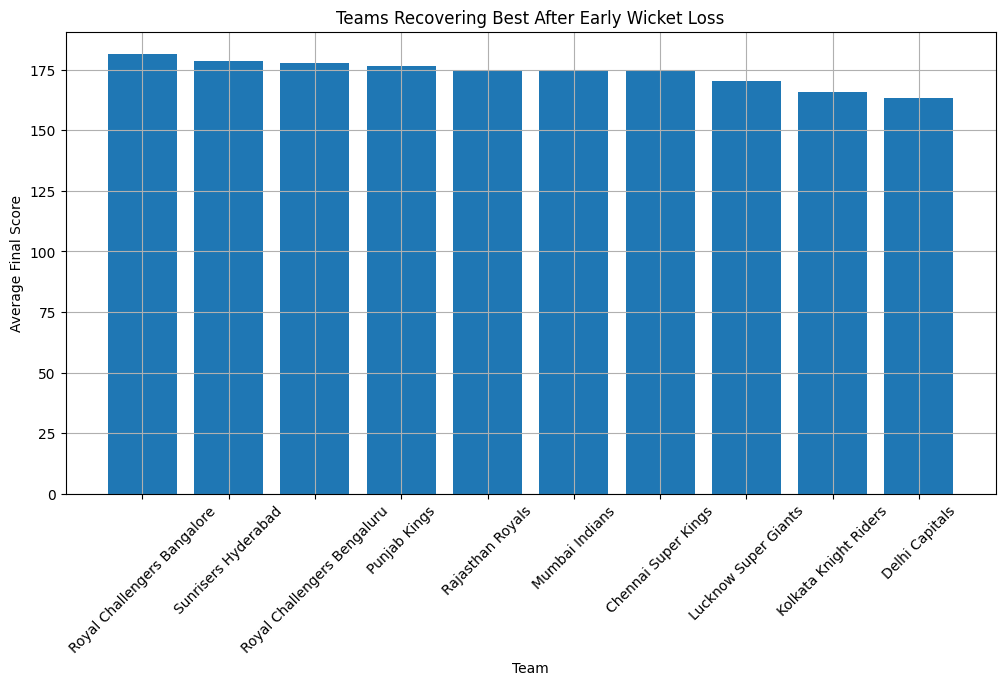

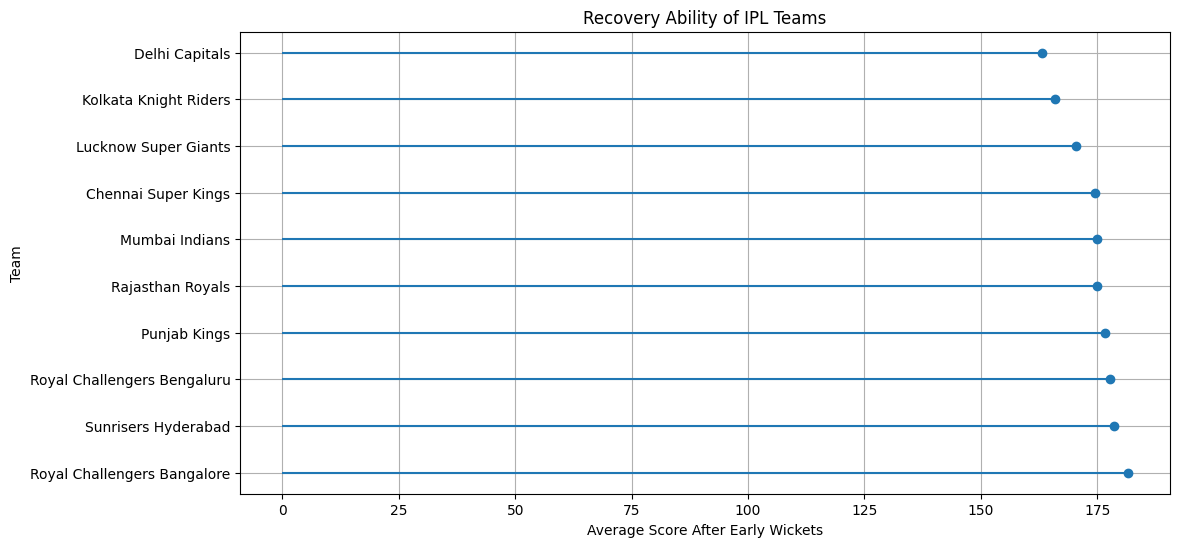

In [ ]:
# QUESTION 5
# Which IPL teams recover best after early wicket loss?

import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("ipl_data.csv")

# Create clean copy
df_clean = df.copy()

# Fix season column
df_clean['season'] = (
    df_clean['season']
    .astype(str)
    .str.strip()
)

# Keep recent IPL seasons
recent_data = df_clean[
    df_clean['season'].str.contains('2023|2024|2025|2026', na=False)
]

# -----------------------------
# STEP 1: Find early wickets
# -----------------------------

early_wickets = recent_data[
    (recent_data['over'] <= 6) &
    (recent_data['wicket_kind'].notna())
]

# Count wickets lost in powerplay
early_wicket_matches = (
    early_wickets.groupby(['match_id', 'batting_team'])
    .size()
    .reset_index(name='early_wickets')
)

# Keep teams losing at least 2 wickets early
early_wicket_matches = early_wicket_matches[
    early_wicket_matches['early_wickets'] >= 2
]

# -----------------------------
# STEP 2: Calculate total score
# -----------------------------

team_totals = (
    recent_data.groupby(['match_id', 'batting_team'])['runs_total']
    .sum()
    .reset_index()
)

# -----------------------------
# STEP 3: Merge datasets
# -----------------------------

recovery_analysis = pd.merge(
    early_wicket_matches,
    team_totals,
    on=['match_id', 'batting_team']
)

# -----------------------------
# STEP 4: Average recovery score
# -----------------------------

team_recovery = (
    recovery_analysis.groupby('batting_team')['runs_total']
    .mean()
    .reset_index()
)

# Sort highest recovery first
team_recovery = team_recovery.sort_values(
    by='runs_total',
    ascending=False
)

# Top 10 teams
top_recovery = team_recovery.head(10)

# -----------------------------
# STEP 5: Print results
# -----------------------------

print(top_recovery)

# -----------------------------
# STEP 6: Main Graph
# -----------------------------

plt.figure(figsize=(12,6))

plt.bar(
    top_recovery['batting_team'],
    top_recovery['runs_total']
)

plt.xticks(rotation=45)

plt.title("Teams Recovering Best After Early Wicket Loss")

plt.xlabel("Team")
plt.ylabel("Average Final Score")

plt.grid(True)

plt.show()

# -----------------------------
# STEP 7: Unique Graph
# -----------------------------

plt.figure(figsize=(12,6))

plt.hlines(
    y=top_recovery['batting_team'],
    xmin=0,
    xmax=top_recovery['runs_total']
)

plt.plot(
    top_recovery['runs_total'],
    top_recovery['batting_team'],
    "o"
)

plt.title("Recovery Ability of IPL Teams")

plt.xlabel("Average Score After Early Wickets")
plt.ylabel("Team")

plt.grid(True)

plt.show()